# 05 – Metadata Analysis

In this notebook, I explore and analyze the new metadata file provided by Manuel (`J20451-313.ccfpar.dat`). This file contains the following columns:

- **BJD**: Barycentric Julian Date
- **RV**: Radial velocity
- **FWHM**: Full Width at Half Maximum
- **CONTRAST**: Line contrast from Cross-Correlation Function (CCF)
- **BIS**: Bisector Inverse Slope
- Corresponding errors: **RV_err**, **FWHM_err**, **CONTRAST_err**, **BIS_err**

The goal is to:

- Load and inspect the metadata
- Align it with existing spectral observations
- Perform exploratory analysis and visualize temporal patterns
- Investigate correlations with latent representations from previous notebooks

This metadata complements my earlier analyses and may help interpret latent dimensions derived from the autoencoder, specifically highlighting stellar activity and rotation.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from datetime import datetime
from astropy.time import Time
from astropy.io import fits
import seaborn as sns

In [2]:
metadata_file = "../../aumicAE1/data/J20451-313.ccfpar.dat"

columns = [
    "BJD", "RV", "FWHM", "CONTRAST", "BIS",
    "RV_err", "FWHM_err", "CONTRAST_err", "BIS_err"
]

metadata = pd.read_csv(metadata_file, delim_whitespace=True, names=columns, comment='#')
metadata.head()

/tmp/ipykernel_36238/2391637873.py:8: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  metadata = pd.read_csv(metadata_file, delim_whitespace=True, names=columns, comment='#')


,BJD,RV,FWHM,CONTRAST,BIS,RV_err,FWHM_err,CONTRAST_err,BIS_err
0,2.458679e+06,-5.328574,12.673912,10.063694,0.306980,0.012692,0.077585,0.048857,0.034974
1,2.458679e+06,-5.355067,12.701133,10.121303,0.323783,0.012501,0.078990,0.049907,0.034504
2,2.458680e+06,-5.008305,12.220235,7.271535,-0.081408,0.009027,0.064395,0.030526,0.022669
3,2.458680e+06,-4.998256,12.137853,7.457874,-0.092328,0.008644,0.058729,0.028773,0.021482
4,2.458681e+06,-5.048751,12.359634,9.902224,-0.103738,0.007096,0.055803,0.035579,0.018071


### Metadata Overview

The dataset contains:
- **BJD**: Time in Barycentric Julian Date format, which I will use to align with spectral observations.
- **RV, FWHM, CONTRAST, BIS**: Activity indicators derived from CCF measurements.
- **Errors**: Associated uncertainties for each measurement.

Next, I'll perform some basic exploratory analysis.

In [3]:
metadata.describe()

,BJD,RV,FWHM,CONTRAST,BIS,RV_err,FWHM_err,CONTRAST_err,BIS_err
count,7.500000e+01,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000
mean,2.458717e+06,-5.056370,12.356764,9.953439,-0.067568,0.008841,0.072218,0.046178,0.022351
std,2.869446e+01,0.137164,0.207868,0.475726,0.178175,0.003291,0.014079,0.008567,0.008526
min,2.458679e+06,-5.355067,11.960256,7.271535,-0.479087,0.005370,0.045331,0.028773,0.013463
25%,2.458694e+06,-5.168763,12.203997,9.859404,-0.179757,0.006542,0.063119,0.040604,0.016428
50%,2.458711e+06,-5.045355,12.356087,10.056935,-0.057106,0.007925,0.071745,0.045967,0.019662
75%,2.458744e+06,-4.940693,12.463269,10.161242,0.065393,0.009731,0.081010,0.051756,0.024984
max,2.458766e+06,-4.791144,12.838715,10.414872,0.323783,0.020967,0.103953,0.063485,0.053882


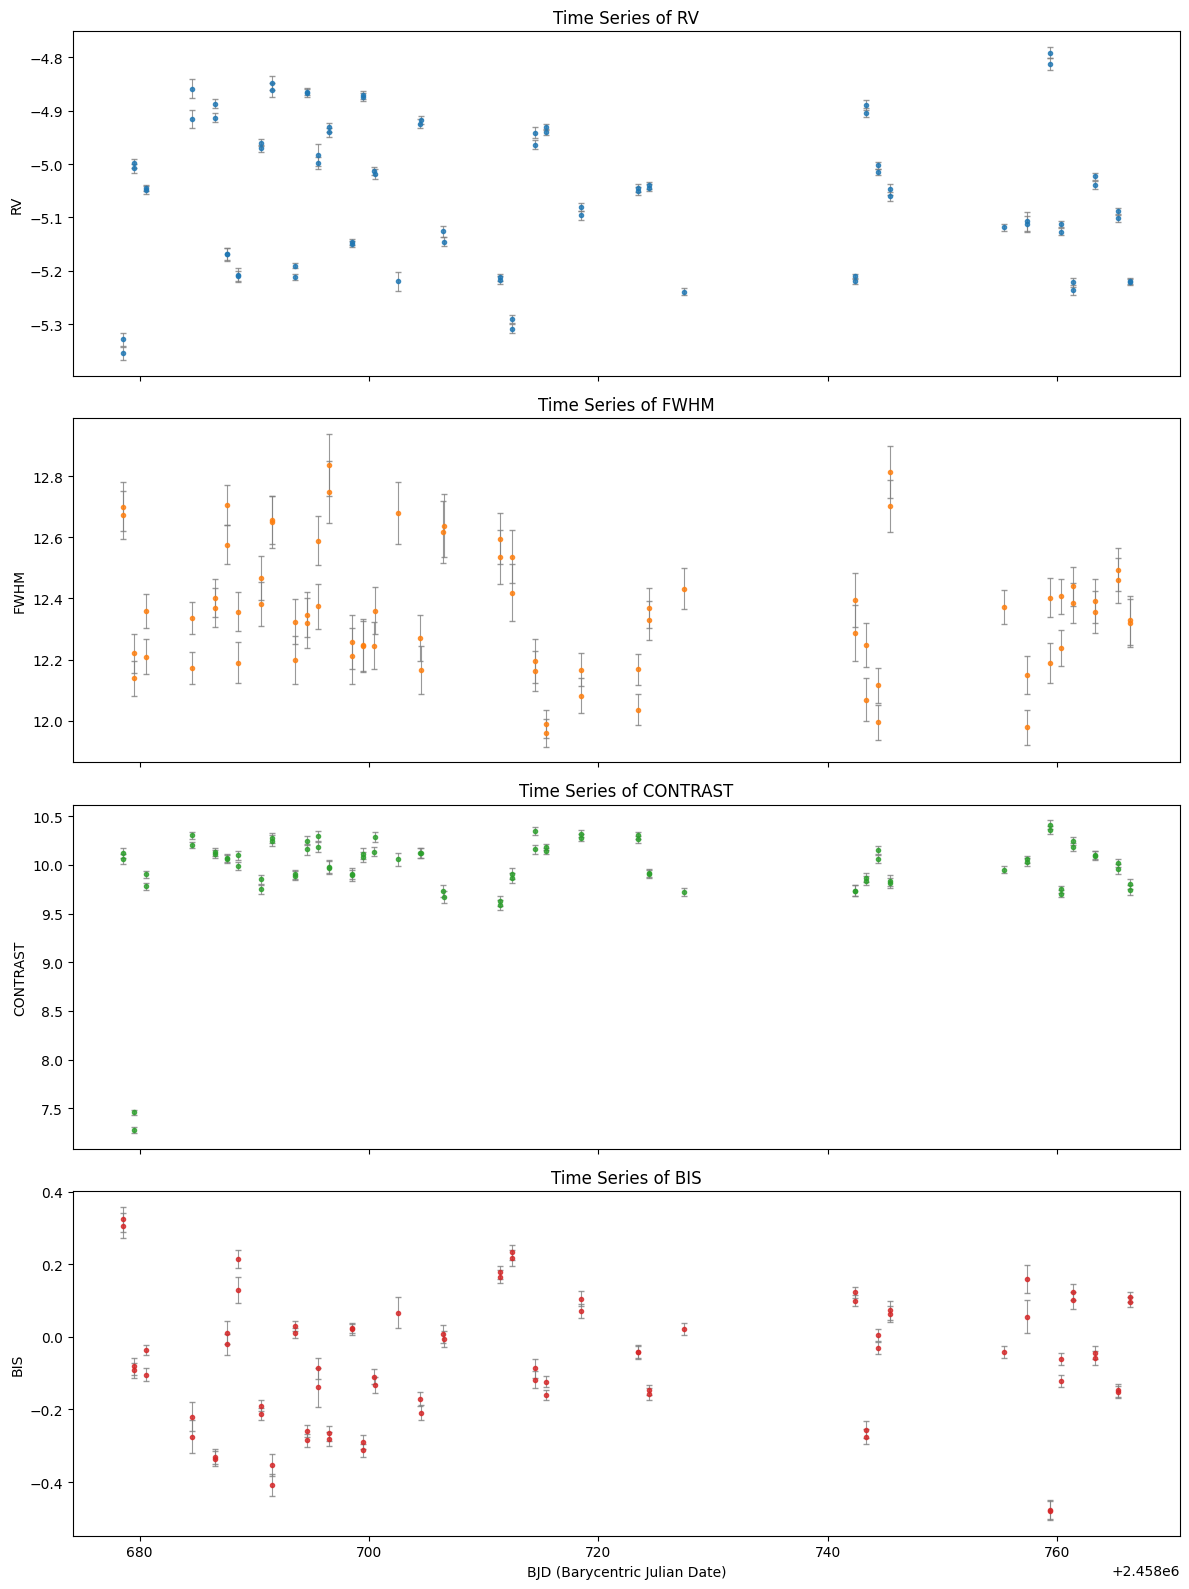

In [4]:
fig, axs = plt.subplots(4, 1, figsize=(12, 16), sharex=True)

indicators = ["RV", "FWHM", "CONTRAST", "BIS"]
colors = ["tab:blue", "tab:orange", "tab:green", "tab:red"]

for i, indicator in enumerate(indicators):
    axs[i].errorbar(metadata["BJD"], metadata[indicator],
                    yerr=metadata[f"{indicator}_err"],
                    fmt='.', color=colors[i], alpha=0.8, ecolor='gray', elinewidth=0.8, capsize=2)
    axs[i].set_ylabel(indicator)
    axs[i].set_title(f"Time Series of {indicator}")

axs[-1].set_xlabel("BJD (Barycentric Julian Date)")

plt.tight_layout()
plt.show()

These plots help me visualize variability in key stellar activity indicators. Clearly visible periodic patterns may correspond to stellar rotation or magnetic activity cycles. 

Next, I will align these metadata observations with the timestamps from my previously analyzed FITS spectra to facilitate comparisons and correlations with latent vectors.

In [5]:
fits_root = "../../aumicAE1"

with open("../data/carvis_visA/vis_a_files.txt", "r") as f:
    vis_a_files = [os.path.join(fits_root, line.strip().lstrip("../")) for line in f if line.strip()]

def extract_datetime_from_filename(path):
    fname = os.path.basename(path)
    date_str = fname.split("-")[1].replace("T", "")
    return datetime.strptime(date_str, "%Y%m%d%Hh%Mm%Ss")

timestamps = [extract_datetime_from_filename(f) for f in vis_a_files]
timestamps = pd.to_datetime(timestamps)

timestamps_df = pd.DataFrame({
    "timestamp": timestamps,
    "file_path": vis_a_files
})

timestamps_df.head()

,timestamp,file_path
0,2019-07-14 01:22:54,../../aumicAE1/data/AUMic/CARVIS/car-20190714T...
1,2019-07-14 01:30:00,../../aumicAE1/data/AUMic/CARVIS/car-20190714T...
2,2019-07-15 00:38:40,../../aumicAE1/data/AUMic/CARVIS/car-20190715T...
3,2019-07-15 00:45:31,../../aumicAE1/data/AUMic/CARVIS/car-20190715T...
4,2019-07-16 00:32:03,../../aumicAE1/data/AUMic/CARVIS/car-20190716T...


Next, I will convert both sets of timestamps (metadata and spectral files) to a consistent format (e.g., BJD) and match spectral observations to the nearest metadata points.

In [6]:
# Convert spectral timestamps to BJD for alignment
timestamps_df["BJD"] = timestamps_df["timestamp"].apply(
    lambda dt: Time(dt).jd  # Convert to Julian Date
)

# Now align each spectrum with nearest metadata entry
aligned_metadata = []

for obs_bjd in timestamps_df["BJD"]:
    idx = np.abs(metadata["BJD"] - obs_bjd).idxmin()
    aligned_metadata.append(metadata.iloc[idx])

aligned_metadata_df = pd.DataFrame(aligned_metadata).reset_index(drop=True)
aligned_metadata_df.head()

,BJD,RV,FWHM,CONTRAST,BIS,RV_err,FWHM_err,CONTRAST_err,BIS_err
0,2.458679e+06,-5.328574,12.673912,10.063694,0.306980,0.012692,0.077585,0.048857,0.034974
1,2.458679e+06,-5.328574,12.673912,10.063694,0.306980,0.012692,0.077585,0.048857,0.034974
2,2.458680e+06,-5.008305,12.220235,7.271535,-0.081408,0.009027,0.064395,0.030526,0.022669
3,2.458680e+06,-5.008305,12.220235,7.271535,-0.081408,0.009027,0.064395,0.030526,0.022669
4,2.458681e+06,-5.048751,12.359634,9.902224,-0.103738,0.007096,0.055803,0.035579,0.018071


**Extract HALPHA and SNR from FITS headers**

In [7]:
halpha_list = []
snr_25_list = []  # Hα
snr_46_list = []  # Ca II 8498-8542 Å
snr_47_list = []  # Ca II 8662 Å

for file in vis_a_files:
    with fits.open(file) as hdul:
        header = hdul[0].header
        halpha = header.get('HIERARCH CARACAL SERVAL HALPHA', np.nan)
        snr_25 = header.get('HIERARCH CARACAL FOX SNR 30', np.nan)  # Hα (Order 25)
        snr_46 = header.get('HIERARCH CARACAL FOX SNR 7', np.nan)   # Order 46 (Ca II)
        snr_47 = header.get('HIERARCH CARACAL FOX SNR 6', np.nan)   # Order 47 (Ca II)

        halpha_list.append(halpha)
        snr_25_list.append(snr_25)
        snr_46_list.append(snr_46)
        snr_47_list.append(snr_47)

fits_metadata_df = pd.DataFrame({
    'HALPHA': halpha_list,
    'SNR_25': snr_25_list,
    'SNR_46': snr_46_list,
    'SNR_47': snr_47_list
})


Now I have each spectral observation aligned with the closest metadata entry. I'll save this aligned data for easy access later:

In [8]:
aligned_metadata_df = pd.concat([aligned_metadata_df.reset_index(drop=True),
                                 fits_metadata_df.reset_index(drop=True)], axis=1)

aligned_metadata_df.to_csv("../outputs/aligned_metadata/aligned_metadata.csv", index=False)


## Next Steps

With this metadata successfully aligned to my spectral observations, I can proceed to:

- Correlate **RV**, **FWHM**, **CONTRAST**, **BIS**, and their errors with latent representations from autoencoder analyses.
- Investigate if latent dimensions clearly track activity indicators.
- Determine optimal strategies for noise removal based on metadata insights.

This notebook sets the stage for a detailed integration of spectral modeling and stellar activity metadata.

## **Correlation Analysis between Latent Dimensions and Stellar-Activity Indicators**

In this section, I compute correlations between latent representations obtained from the autoencoder and the stellar-activity indicators from the metadata (RV, FWHM, CONTRAST, BIS, Hα, SNR).

The aim is to identify if latent dimensions effectively capture physical stellar-activity signals.

In [9]:
latent_vectors = np.load("../outputs/latent/latent_vectors_orders25_46_47_denoised.npy")
latent_df = pd.DataFrame(latent_vectors.reshape(latent_vectors.shape[0], -1))
latent_df.columns = [f'Latent_{i}' for i in range(latent_df.shape[1])]

print("Latent dimensions:", latent_df.shape[1])
print("Latent Represetaion of the first 5 spectra (using only the three selected orders and based on the denosing autoencoder from '04_improve_autoencoder.ipynb'):")
latent_df.head()

Latent dimensions: 32
Latent Represetaion of the first 5 spectra (using only the three selected orders and based on the denosing autoencoder from '04_improve_autoencoder.ipynb'):


,Latent_0,Latent_1,Latent_2,Latent_3,Latent_4,Latent_5,Latent_6,Latent_7,Latent_8,Latent_9,...,Latent_22,Latent_23,Latent_24,Latent_25,Latent_26,Latent_27,Latent_28,Latent_29,Latent_30,Latent_31
0,-0.038836,-0.204807,0.213359,0.137147,0.277484,0.029612,-0.120309,0.262803,-0.207805,-0.214267,...,0.233198,-0.089645,0.117982,0.269939,0.136544,-0.180571,0.096550,0.225003,-0.136485,0.227147
1,-0.025149,-0.218068,0.209765,0.149130,0.246386,0.031148,-0.121687,0.271954,-0.185723,-0.218950,...,0.202747,-0.088070,0.090568,0.272936,0.132025,-0.179274,0.104373,0.216082,-0.122408,0.212270
2,0.149852,0.114121,0.104258,-0.227779,-0.052601,-0.377383,0.208223,-0.284792,0.372651,0.045014,...,-0.315584,0.151711,0.055616,-0.335908,-0.227544,0.207458,-0.175736,-0.255675,0.144468,0.011197
3,0.177149,0.143550,0.098220,-0.262175,-0.064088,-0.395094,0.226536,-0.326778,0.396169,0.085268,...,-0.359454,0.165820,0.030908,-0.384713,-0.274453,0.225202,-0.211563,-0.279759,0.150190,0.007812
4,0.084016,0.087185,0.055965,-0.130976,-0.002706,-0.175292,0.115703,-0.163001,0.200059,0.040458,...,-0.182966,0.072073,0.025069,-0.192384,-0.145166,0.131552,-0.093652,-0.161123,0.065332,-0.009605


In [10]:
aligned_metadata_df = pd.read_csv("../outputs/aligned_metadata/aligned_metadata.csv")
print("The corresponding metadata (activity indicators and Signal-to-Nosise-Ratios) of the first 5 spectra:")
aligned_metadata_df.head()

The corresponding metadata (activity indicators and Signal-to-Nosise-Ratios) of the first 5 spectra:


,BJD,RV,FWHM,CONTRAST,BIS,RV_err,FWHM_err,CONTRAST_err,BIS_err,HALPHA,SNR_25,SNR_46,SNR_47
0,2.458679e+06,-5.328574,12.673912,10.063694,0.306980,0.012692,0.077585,0.048857,0.034974,2.69504,50.104,14.105,13.335
1,2.458679e+06,-5.328574,12.673912,10.063694,0.306980,0.012692,0.077585,0.048857,0.034974,2.70468,51.253,11.739,10.940
2,2.458680e+06,-5.008305,12.220235,7.271535,-0.081408,0.009027,0.064395,0.030526,0.022669,3.53532,98.046,25.750,23.613
3,2.458680e+06,-5.008305,12.220235,7.271535,-0.081408,0.009027,0.064395,0.030526,0.022669,3.70245,99.969,26.002,23.719
4,2.458681e+06,-5.048751,12.359634,9.902224,-0.103738,0.007096,0.055803,0.035579,0.018071,3.08575,93.477,14.924,12.876


In [11]:
full_df = pd.concat([aligned_metadata_df.reset_index(drop=True), latent_df.reset_index(drop=True)], axis=1)
print("Merged DataFrame shape:", full_df.shape)
full_df.head()

Merged DataFrame shape: (95, 45)


,BJD,RV,FWHM,CONTRAST,BIS,RV_err,FWHM_err,CONTRAST_err,BIS_err,HALPHA,...,Latent_22,Latent_23,Latent_24,Latent_25,Latent_26,Latent_27,Latent_28,Latent_29,Latent_30,Latent_31
0,2.458679e+06,-5.328574,12.673912,10.063694,0.306980,0.012692,0.077585,0.048857,0.034974,2.69504,...,0.233198,-0.089645,0.117982,0.269939,0.136544,-0.180571,0.096550,0.225003,-0.136485,0.227147
1,2.458679e+06,-5.328574,12.673912,10.063694,0.306980,0.012692,0.077585,0.048857,0.034974,2.70468,...,0.202747,-0.088070,0.090568,0.272936,0.132025,-0.179274,0.104373,0.216082,-0.122408,0.212270
2,2.458680e+06,-5.008305,12.220235,7.271535,-0.081408,0.009027,0.064395,0.030526,0.022669,3.53532,...,-0.315584,0.151711,0.055616,-0.335908,-0.227544,0.207458,-0.175736,-0.255675,0.144468,0.011197
3,2.458680e+06,-5.008305,12.220235,7.271535,-0.081408,0.009027,0.064395,0.030526,0.022669,3.70245,...,-0.359454,0.165820,0.030908,-0.384713,-0.274453,0.225202,-0.211563,-0.279759,0.150190,0.007812
4,2.458681e+06,-5.048751,12.359634,9.902224,-0.103738,0.007096,0.055803,0.035579,0.018071,3.08575,...,-0.182966,0.072073,0.025069,-0.192384,-0.145166,0.131552,-0.093652,-0.161123,0.065332,-0.009605


#### Correlation Matrix Computation

I now compute correlations (Pearson’s) between each latent dimension and each stellar-activity indicator.

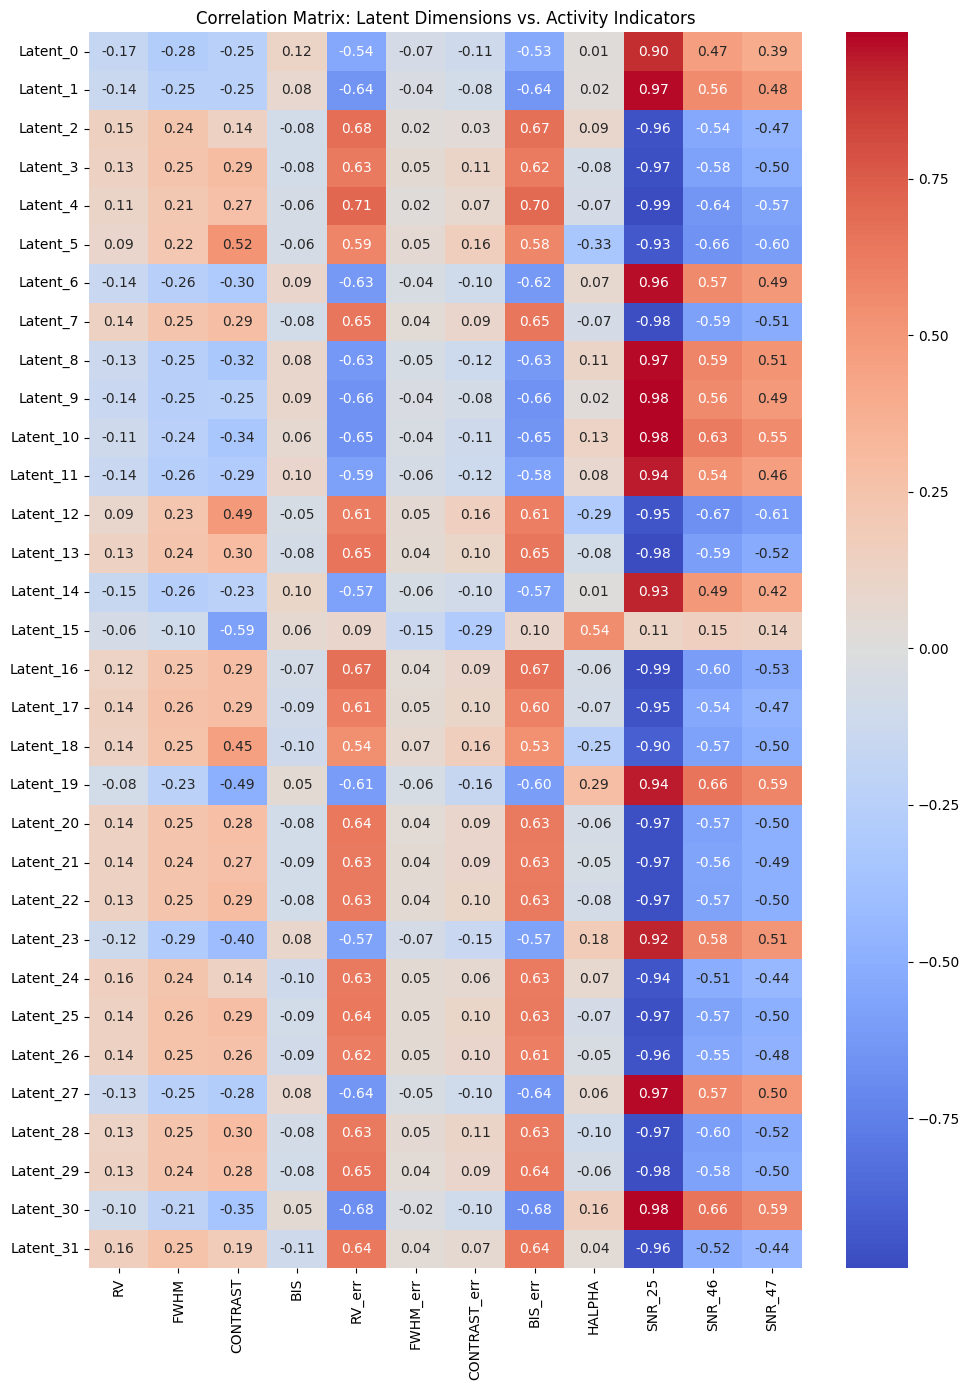

In [12]:
corr_columns = ['RV', 'FWHM', 'CONTRAST', 'BIS', 'RV_err', 'FWHM_err', 'CONTRAST_err', 'BIS_err',
                'HALPHA', 'SNR_25', 'SNR_46', 'SNR_47']
latent_columns = [col for col in full_df.columns if 'Latent_' in col]

correlation_matrix = full_df[latent_columns + corr_columns].corr().loc[latent_columns, corr_columns]

plt.figure(figsize=(10, 14))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt=".2f")
plt.title("Correlation Matrix: Latent Dimensions vs. Activity Indicators")
plt.tight_layout()

os.makedirs("../outputs/plots", exist_ok=True)
plt.savefig("../outputs/plots/correlation_latent_activity.png", dpi=150)
plt.show()

From this latest correlation plot:

- Hα (from the SERVAL pipeline, tracing chromospheric activity) is most strongly correlated with Latent_15, with a Pearson correlation coefficient of 0.54.

- This means that Latent_15 captures variability that's strongly related to chromospheric activity in AU Mic - potentially modulated by spots, plages, or flares.

- No other latent dimension reaches similar levels of correlation with Hα - most hover near zero or even show weak negative correlation.

This may suggest that my autoencoder learns a structured representation where at least one latent coordinate captures real physical activity in the star.

(This dimension (Latent_15) might even be used to filter out activity-driven spectral variability, or as a proxy activity indicator, especially if future models are trained to regress it out from RVs.)

**High correlation with SNR_25**

→ My autoencoder is learning to encode noise levels, not just spectral features.
The model is picking up how good/bad the quality of each spectrum is. That’s not ideal - it reduces generalization.

**Latent_15 not correlated with SNR_25, but with Hα**

→ This is good! Latent_15 is likely learning actual physical variation (activity), not just noise. That’s the kind of latent feature I want - one that tracks astrophysics, not data quality.

##### **We have to take care of the noise!**